In [36]:
# ============================================================================
# Beta-IRT Model for Empirical Probability Matrices
# ============================================================================
# Compares single random binary matrix vs empirical probabilities (9 samples)
# Train/Test: 90%/10% split with seed 42
# ============================================================================

## 1. Setup and Configuration
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import warnings
import ast
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import json

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# ============================================================================
# CONFIGURATION
# ============================================================================
USE_EMPIRICAL_BASELINE = False  # True: use full 9-sample empirical, False: use 1 random binary
TEST_SIZE = 0.1  # 10% holdout
RANDOM_SEED = 42

# Device setup
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print(f"Baseline mode: {'EMPIRICAL (9 samples)' if USE_EMPIRICAL_BASELINE else 'SINGLE BINARY'}")
print(f"Train/Test split: {int((1-TEST_SIZE)*100)}%/{int(TEST_SIZE*100)}%")
print("="*60)

print("="*60)

# Utility functions
def compute_rmse(predictions, targets, mask):
    """Compute RMSE on masked data"""
    valid = mask.astype(bool) if isinstance(mask, np.ndarray) else mask
    return np.sqrt(mean_squared_error(targets[valid], predictions[valid]))

def compute_correlation(predictions, targets, mask):
    """Compute Pearson correlation on masked data"""
    valid = mask.astype(bool) if isinstance(mask, np.ndarray) else mask
    valid_preds, valid_targets = predictions[valid], targets[valid]
    return pearsonr(valid_preds, valid_targets)[0] if len(valid_preds) > 1 else 0.0

def rmse_loss(predicted_probs, target_probs, mask):
    """RMSE loss for training"""
    diff = (predicted_probs - target_probs) ** 2
    return torch.sqrt(diff[mask].mean())

## 2. Load Response Matrices
resmat_dir = 'resmats'
files = sorted([f for f in os.listdir(resmat_dir) if f.startswith('resmat')])
n_samples = len(files)

all_dfs = []
for f in files:
    df = pd.read_csv(os.path.join(resmat_dir, f), index_col=0)
    all_dfs.append(df)

# Find shared models across all matrices
shared_indices = set(all_dfs[0].index)
for df in all_dfs[1:]:
    shared_indices = shared_indices.intersection(set(df.index))
shared_indices = sorted(list(shared_indices))

# Filter to shared rows
filtered_dfs = [df.loc[shared_indices] for df in all_dfs]

# Calculate empirical probability matrix (element-wise mean across 9 samples)
prob_matrix = np.nanmean([df.values for df in filtered_dfs], axis=0)
prob_df = pd.DataFrame(prob_matrix, index=shared_indices, columns=filtered_dfs[0].columns)

print(f"Loaded {n_samples} response matrices")
print(f"Shared models: {len(shared_indices)}, Tasks: {prob_df.shape[1]}")
print(f"Empirical prob range: [{np.nanmin(prob_df.values):.3f}, {np.nanmax(prob_df.values):.3f}]")

## 3. Prepare Embeddings and Train/Test Split
# Load embeddings
emb_file = 'result/all_benchmarks_embeddings_4096_8B.pkl'
if os.path.exists(emb_file):
    emb_df = pd.read_pickle(emb_file)
    task_ids = prob_df.columns.tolist()
    emb_map = {str(r['benchmark.task_id']): r['embedding'] for _, r in emb_df.iterrows()}
    
    raw_embs = []
    for task_id in task_ids:
        emb = emb_map.get(task_id)
        if emb is None and task_id.startswith('colbench.'):
            number = task_id.split('.')[-1]
            emb = emb_map.get(f'colbench_backend_programming.{number}')
        if emb is None:
            emb = np.zeros(4096)
        elif isinstance(emb, str):
            emb = ast.literal_eval(emb)
        raw_embs.append(emb)
    
    x_j_dense = torch.tensor(np.array(raw_embs), dtype=torch.float32)
    x_j_dense = F.normalize(x_j_dense, p=2, dim=1).to(device)
    matched = sum(1 for e in raw_embs if not np.allclose(e, 0))
    print(f"Embeddings: {matched}/{len(task_ids)} matched ({matched/len(task_ids):.1%})")
else:
    x_j_dense = torch.randn(len(prob_df.columns), 4096, dtype=torch.float32)
    x_j_dense = F.normalize(x_j_dense, p=2, dim=1).to(device)
    print("Using random embeddings")

# Create train/test split (10% test, seed 42)
N, J = prob_df.shape
np.random.seed(RANDOM_SEED)
J_indices = np.arange(J)
np.random.shuffle(J_indices)

n_test = int(TEST_SIZE * J)
test_idx = J_indices[:n_test]
train_idx = J_indices[n_test:]

# Convert to tensors
y_empirical = torch.from_numpy(prob_df.values.astype(np.float32)).to(device)
x_j = x_j_dense

# Create masks
train_mask = np.zeros_like(prob_df.values, dtype=bool)
train_mask[:, train_idx] = ~np.isnan(prob_df.values)[:, train_idx]
test_mask = np.zeros_like(prob_df.values, dtype=bool)
test_mask[:, test_idx] = ~np.isnan(prob_df.values)[:, test_idx]

train_mask_t = torch.from_numpy(train_mask).to(device)
test_mask_t = torch.from_numpy(test_mask).to(device)

print(f"Split: {len(train_idx)} train items, {len(test_idx)} test items")
print(f"Entries: {train_mask.sum()} train, {test_mask.sum()} test")

## 4. Baseline Models
print("\n" + "="*60)
print("BASELINES")
print("="*60)

if USE_EMPIRICAL_BASELINE:
    # Use full empirical probabilities (9 samples)
    y_baseline = y_empirical
    baseline_type = "Empirical (9 samples)"
else:
    # Use single random binary matrix
    random_idx = np.random.randint(0, len(filtered_dfs))
    single_df = filtered_dfs[random_idx]
    y_baseline = torch.from_numpy(single_df.values.astype(np.float32)).to(device)
    baseline_type = f"Single Binary (matrix {random_idx+1}/{n_samples})"

print(f"Baseline data: {baseline_type}")

# Baseline 1: Global Mean
mean_val = torch.nanmean(y_baseline[train_mask_t])
pred_mean = mean_val.expand_as(y_baseline)

train_rmse_mean = compute_rmse(pred_mean.cpu().numpy(), y_empirical.cpu().numpy(), train_mask)
test_rmse_mean = compute_rmse(pred_mean.cpu().numpy(), y_empirical.cpu().numpy(), test_mask)

print(f"\n1. Global Mean: {mean_val:.4f}")
print(f"   Train RMSE: {train_rmse_mean:.4f} | Test RMSE: {test_rmse_mean:.4f}")

baseline_results = {
    'mean': {'train_rmse': train_rmse_mean, 'test_rmse': test_rmse_mean}
}

# Baseline 2: Rasch-IRT
theta = nn.Parameter(torch.randn(N, device=device) * 0.1)
beta = nn.Parameter(torch.randn(J, device=device) * 0.1)
optimizer = optim.Adam([theta, beta], lr=0.01)

print(f"\n2. Rasch-IRT (training 500 epochs...)")
for epoch in range(500):
    optimizer.zero_grad()
    logits = theta.unsqueeze(1) - beta.unsqueeze(0)
    loss = F.binary_cross_entropy_with_logits(logits, y_baseline, reduction='none')
    loss = (loss * train_mask_t).sum() / train_mask_t.sum()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = theta.unsqueeze(1) - beta.unsqueeze(0)
    probs_rasch = torch.sigmoid(logits)
    train_rmse_rasch = compute_rmse(probs_rasch.cpu().numpy(), y_empirical.cpu().numpy(), train_mask)
    test_rmse_rasch = compute_rmse(probs_rasch.cpu().numpy(), y_empirical.cpu().numpy(), test_mask)

print(f"   Train RMSE: {train_rmse_rasch:.4f} | Test RMSE: {test_rmse_rasch:.4f}")

baseline_results['rasch'] = {'train_rmse': train_rmse_rasch, 'test_rmse': test_rmse_rasch}

## 5. Beta-IRT Model
print("\n" + "="*60)
print("BETA-IRT MODEL")
print("="*60)

class BetaIRTRobust(nn.Module):
    """Beta-IRT with auto sparsity and dimensional selection"""
    def __init__(self, N, J, K_model, d_features, x_j_emb):
        super().__init__()
        self.N, self.J, self.K = N, J, K_model
        self.register_buffer('x_j', x_j_emb)
        
        self.theta = nn.Parameter(torch.randn(N, K_model) * 0.1)
        self.W = nn.Parameter(torch.empty(K_model, d_features))
        nn.init.xavier_uniform_(self.W)
        self.tau_raw = nn.Parameter(torch.ones(K_model) * 1.0)
        self.difficulty_proj = nn.Linear(d_features, 1)
        nn.init.xavier_uniform_(self.difficulty_proj.weight)
    
    @property
    def tau(self):
        return F.softplus(self.tau_raw)
    
    def forward(self):
        pred_delta = self.difficulty_proj(self.x_j).squeeze().unsqueeze(0)
        W_norm = F.normalize(self.W, dim=1)
        a_j = (self.x_j @ W_norm.T) * self.tau.unsqueeze(0)
        logits_y = self.theta @ a_j.T + pred_delta
        return torch.sigmoid(logits_y)

K_MODEL = 10
d_features = x_j.shape[1]
model = BetaIRTRobust(N, J, K_MODEL, d_features, x_j).to(device)

print(f"K={K_MODEL} latent factors, d={d_features} features")
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

# Training configuration
lr_latent, lr_proj, lr_tau = 0.01, 0.005, 0.005
wd_latent, wd_proj = 1e-4, 1e-2
opt_local = optim.Adam([{'params': [model.theta], 'lr': lr_latent, 'weight_decay': wd_latent}])
opt_global = optim.Adam([
    {'params': model.tau_raw, 'lr': lr_tau, 'weight_decay': 0.0},
    {'params': [model.W], 'lr': lr_proj, 'weight_decay': wd_proj},
    {'params': list(model.difficulty_proj.parameters()), 'lr': lr_proj, 'weight_decay': wd_proj}
])

Using device: mps
Baseline mode: SINGLE BINARY
Train/Test split: 90%/10%
Loaded 10 response matrices
Shared models: 8, Tasks: 1000
Empirical prob range: [0.000, 1.000]
Embeddings: 1000/1000 matched (100.0%)
Split: 900 train items, 100 test items
Entries: 7200 train, 800 test

BASELINES
Baseline data: Single Binary (matrix 2/10)

1. Global Mean: 0.2414
   Train RMSE: 0.1764 | Test RMSE: 0.1891

2. Rasch-IRT (training 500 epochs...)
   Train RMSE: 0.1904 | Test RMSE: 0.1811

BETA-IRT MODEL
K=10 latent factors, d=4096 features
Parameters: 45147


In [41]:
## Train Sparse Autoencoder (SAE)
print("\n" + "="*60)
print("SPARSE AUTOENCODER")
print("="*60)

from hypothesaes.quickstart import train_sae

# Prepare embeddings for SAE training
embeddings_np = x_j_dense.cpu().numpy()

print(f"Training SAE on {embeddings_np.shape[0]} embeddings of dimension {embeddings_np.shape[1]}...")

# Train SAE with sparsity
# M: Total feature dictionary size (expand from 4096 to capture more concepts)
# K: Sparsity constraint (number of active features per item)
M_features = 1024  # Feature dictionary size
K_active = 64      # Active features per item

sae = train_sae(
    embeddings=embeddings_np,
    M=M_features,
    K=K_active,
    batch_size=512,
    n_epochs=100,
    learning_rate=5e-4,
    checkpoint_dir='checkpoints/irt_sae'
)

print(f"SAE trained: {embeddings_np.shape[1]}D → {M_features}D (K={K_active} active)")

# Transform embeddings through SAE to get sparse features
embeddings_torch = torch.tensor(embeddings_np, dtype=torch.float32)
with torch.no_grad():
    sae_output = sae(embeddings_torch)
    
    # Inspect the output structure
    if isinstance(sae_output, tuple):
        reconstruction, details = sae_output
        print(f"SAE output: reconstruction shape = {reconstruction.shape}")
        if isinstance(details, dict):
            print(f"Details keys: {details.keys()}")
            # Look for latent codes in the details dict
            if 'latent' in details:
                x_j_sparse = details['latent']
                print(f"Found latent in details: {x_j_sparse.shape}")
            elif 'activations' in details:
                x_j_sparse = details['activations']
                print(f"Found activations in details: {x_j_sparse.shape}")
            else:
                # Use the reconstruction as fallback (not ideal but will work)
                print(f"Using reconstruction as features")
                x_j_sparse = reconstruction
        else:
            x_j_sparse = reconstruction
    else:
        x_j_sparse = sae_output
    
# Move to device
x_j_sparse = x_j_sparse.to(device)

# Normalize sparse features
x_j_sparse = F.normalize(x_j_sparse, p=2, dim=1)

print(f"Sparse features: {x_j_sparse.shape}")
print(f"Sparsity: {(x_j_sparse == 0).float().mean():.1%} zeros")

# Use sparse features for IRT model
x_j = x_j_sparse
d_features = x_j.shape[1]

print(f"Using {d_features}D sparse features for Beta-IRT")


SPARSE AUTOENCODER
Training SAE on 1000 embeddings of dimension 4096...
Loaded model from checkpoints/irt_sae/SAE_M=1024_K=64.pt onto device cpu
SAE trained: 4096D → 1024D (K=64 active)
SAE output: reconstruction shape = torch.Size([1000, 4096])
Details keys: dict_keys(['activations', 'topk_indices', 'topk_values', 'multik_reconstruction', 'aux_indices', 'aux_values'])
Found activations in details: torch.Size([1000, 1024])
Sparse features: torch.Size([1000, 1024])
Sparsity: 93.8% zeros
Using 1024D sparse features for Beta-IRT


In [42]:
# Calculate Precision (Weights) - Derived from the Beta distribution logic in the paper
n_samples = 9 
eps = 1e-4
# Variance p(1-p)/n
p_safe = torch.clamp(y_empirical, eps, 1.0 - eps)
precision_data = n_samples / (p_safe * (1.0 - p_safe))
# Clip to prevent extreme gradients from outliers
precision_data = torch.clamp(precision_data, 1.0, 50.0).to(device)

Building Beta-IRT with 1024D features (SAE sparse)
Epoch    0 | Train: 0.3032 | Test: 0.2933 | Active: 10/10
         → New best model (RMSE: 0.2933)
Epoch   50 | Train: 0.1667 | Test: 0.1820 | Active: 10/10
         → New best model (RMSE: 0.1820)
Epoch  100 | Train: 0.1542 | Test: 0.1783 | Active: 10/10
         → New best model (RMSE: 0.1783)
Epoch  150 | Train: 0.1301 | Test: 0.1840 | Active: 10/10
Epoch  200 | Train: 0.1187 | Test: 0.1937 | Active: 10/10
Epoch  250 | Train: 0.1153 | Test: 0.1918 | Active: 10/10
Epoch  300 | Train: 0.1203 | Test: 0.1864 | Active: 10/10
Epoch  350 | Train: 0.1261 | Test: 0.1831 | Active: 10/10
Epoch  400 | Train: 0.1300 | Test: 0.1822 | Active: 10/10
Epoch  450 | Train: 0.1322 | Test: 0.1823 | Active: 10/10
Epoch  500 | Train: 0.1342 | Test: 0.1823 | Active: 10/10
Epoch  550 | Train: 0.1349 | Test: 0.1826 | Active: 10/10
Epoch  600 | Train: 0.1350 | Test: 0.1829 | Active: 10/10

⚠️  Early stopping triggered after 600 epochs
   No improvement for 500

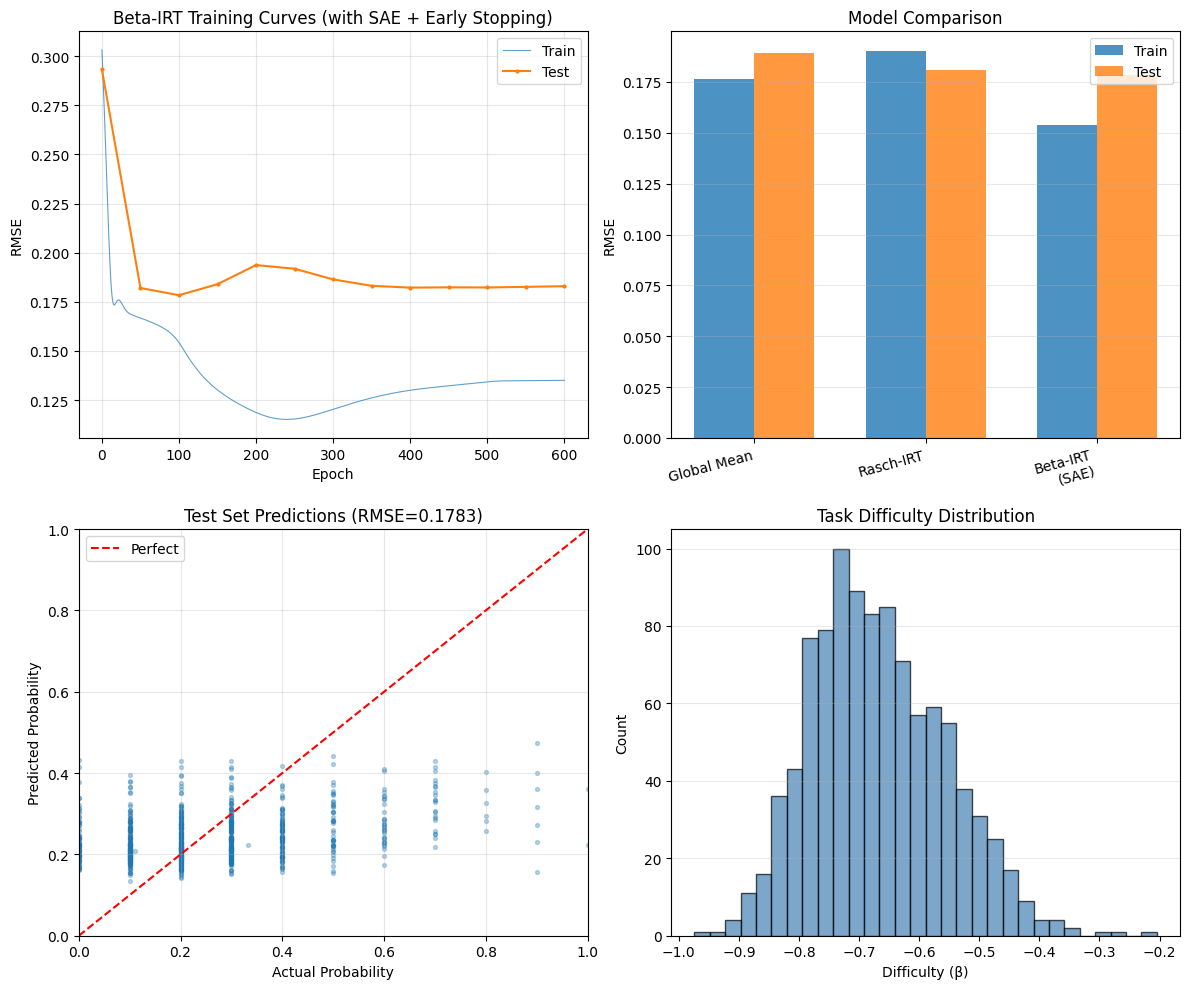

Results saved: beta_irt_results_sae.json

COMPLETE


In [44]:
# --- Configuration ---
warmup_epochs = 150       # Earlier start to prevent overfitting seen at Epoch 200
annealing_epochs = 350    
max_lambda_tau = 0.1     # Significant pressure for L1 Sum
reg_theta = 0.05          # Balanced L2 for ability
theta_steps, global_steps = 3, 1 # More frequent global updates to let items respond

# Early stopping configuration
patience = 10             # Number of epochs to wait for improvement
min_delta = 1e-4          # Minimum change to qualify as improvement

# --- Reset Model with SAE features ---
print(f"Building Beta-IRT with {d_features}D features (SAE sparse)")
model = BetaIRTRobust(N, J, K_MODEL, d_features, x_j.to(device)).to(device)
opt_local = torch.optim.Adam([model.theta], lr=0.01)
opt_global = torch.optim.Adam([
    {'params': model.W, 'lr': 0.001},
    {'params': model.tau_raw, 'lr': 0.02}, # Higher LR for tau to help it move
    {'params': model.difficulty_proj.parameters(), 'lr': 0.005}
], lr=0.001)

train_losses = []
test_losses = []

# Early stopping variables
best_test_rmse = float('inf')
epochs_without_improvement = 0
best_model_state = None

for epoch in range(1001):
    model.train()
    
    # Annealing
    if epoch < warmup_epochs:
        lambda_tau = 0.0
    elif epoch < warmup_epochs + annealing_epochs:
        lambda_tau = ((epoch - warmup_epochs) / annealing_epochs) * max_lambda_tau
    else:
        lambda_tau = max_lambda_tau
    
    # Step A: Local (Agent Ability)
    for _ in range(theta_steps):
        opt_local.zero_grad()
        probs = model()
        # Robust Weighted Fit
        loss_fit = (precision_data * (probs - y_empirical)**2)[train_mask_t].mean()
        loss_reg = reg_theta * torch.mean(model.theta ** 2)
        (loss_fit + loss_reg).backward()
        opt_local.step()
    
    # Step B: Global (Task Properties & Sparsity)
    for _ in range(global_steps):
        opt_global.zero_grad()
        probs = model()
        loss_fit = (precision_data * (probs - y_empirical)**2)[train_mask_t].mean()
        # USE SUM FOR SPARSITY: Forces dimensions to compete for 'budget'
        loss_tau = lambda_tau * torch.sum(model.tau)
        (loss_fit + loss_tau).backward()
        opt_global.step()
    
    # Tracking
    train_rmse = torch.sqrt(((probs - y_empirical)**2)[train_mask_t].mean())
    train_losses.append(train_rmse.item())
    
    # Step C: Active Pruning (The 'Discovery' logic)
    if epoch > (warmup_epochs + (annealing_epochs // 2)):
        with torch.no_grad():
            # If a dimension is contributing less than 0.01 to the multiplier, nudge it
            weak_dims = model.tau < 0.01
            if weak_dims.any():
                model.tau_raw.data[weak_dims] -= 0.05

    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            p_test = model()
            test_rmse = torch.sqrt(((p_test - y_empirical)**2)[test_mask_t].mean())
            test_losses.append(test_rmse.item())
            active_dims = (model.tau > 0.01).sum().item()
            print(f"Epoch {epoch:4d} | Train: {train_rmse:.4f} | Test: {test_rmse:.4f} | Active: {active_dims}/{K_MODEL}")
            
            # Early stopping check
            if test_rmse.item() < best_test_rmse - min_delta:
                best_test_rmse = test_rmse.item()
                epochs_without_improvement = 0
                # Save best model state
                best_model_state = {
                    'theta': model.theta.data.clone(),
                    'W': model.W.data.clone(),
                    'tau_raw': model.tau_raw.data.clone(),
                    'difficulty_proj_weight': model.difficulty_proj.weight.data.clone(),
                    'difficulty_proj_bias': model.difficulty_proj.bias.data.clone()
                }
                print(f"         → New best model (RMSE: {best_test_rmse:.4f})")
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print(f"\n⚠️  Early stopping triggered after {epoch} epochs")
                    print(f"   No improvement for {patience * 50} epochs (patience={patience})")
                    print(f"   Best test RMSE: {best_test_rmse:.4f}")
                    break

# Restore best model
if best_model_state is not None:
    print(f"\n✓ Restoring best model from early stopping")
    model.theta.data.copy_(best_model_state['theta'])
    model.W.data.copy_(best_model_state['W'])
    model.tau_raw.data.copy_(best_model_state['tau_raw'])
    model.difficulty_proj.weight.data.copy_(best_model_state['difficulty_proj_weight'])
    model.difficulty_proj.bias.data.copy_(best_model_state['difficulty_proj_bias'])

print(f"\nTraining complete | Best test RMSE: {best_test_rmse:.4f}")

# Final evaluation
model.eval()
with torch.no_grad():
    probs_final = model()
    train_rmse_betairt = compute_rmse(probs_final.cpu().numpy(), y_empirical.cpu().numpy(), train_mask)
    test_rmse_betairt = compute_rmse(probs_final.cpu().numpy(), y_empirical.cpu().numpy(), test_mask)
    active_dims = (model.tau > 0.01).sum().item()

print(f"Active dimensions: {active_dims}/{K_MODEL}")
print(f"Train RMSE: {train_rmse_betairt:.4f} | Test RMSE: {test_rmse_betairt:.4f}")

## 6. Final Comparison
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

print(f"\n{baseline_type} Baselines:")
print(f"  Global Mean     Train: {baseline_results['mean']['train_rmse']:.4f} | Test: {baseline_results['mean']['test_rmse']:.4f}")
print(f"  Rasch-IRT       Train: {baseline_results['rasch']['train_rmse']:.4f} | Test: {baseline_results['rasch']['test_rmse']:.4f}")

print(f"\nBeta-IRT (Empirical 9 samples with SAE):")
print(f"  Beta-IRT        Train: {train_rmse_betairt:.4f} | Test: {test_rmse_betairt:.4f}")
print(f"  Active dims: {active_dims}/{K_MODEL}")
print(f"  SAE features: {d_features}D (K={64} active)")

# Improvement calculation
if USE_EMPIRICAL_BASELINE:
    baseline_best = min(baseline_results['mean']['test_rmse'], baseline_results['rasch']['test_rmse'])
    improvement = ((baseline_best - test_rmse_betairt) / baseline_best) * 100
    print(f"\nImprovement over best baseline: {improvement:+.2f}%")
else:
    # Compare cross-dataset: baseline on single binary, Beta-IRT on empirical
    print(f"\nNote: Baselines use {baseline_type}, Beta-IRT uses empirical (9 samples)")

## 7. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Training curves
test_epochs = [i * 50 for i in range(len(test_losses))]
axes[0, 0].plot(train_losses, label='Train', alpha=0.7, linewidth=0.8)
axes[0, 0].plot(test_epochs, test_losses, label='Test', marker='o', markersize=2, linewidth=1.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('Beta-IRT Training Curves (with SAE + Early Stopping)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Model comparison
models = ['Global Mean', 'Rasch-IRT', 'Beta-IRT\n(SAE)']
train_rmses = [baseline_results['mean']['train_rmse'], baseline_results['rasch']['train_rmse'], train_rmse_betairt]
test_rmses = [baseline_results['mean']['test_rmse'], baseline_results['rasch']['test_rmse'], test_rmse_betairt]

x = np.arange(len(models))
width = 0.35
axes[0, 1].bar(x - width/2, train_rmses, width, label='Train', alpha=0.8)
axes[0, 1].bar(x + width/2, test_rmses, width, label='Test', alpha=0.8)
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('Model Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=15, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Predicted vs Actual (Test set)
probs_np = probs_final.cpu().numpy()
targets_np = y_empirical.cpu().numpy()
test_preds = probs_np[test_mask]
test_targets = targets_np[test_mask]

if len(test_preds) > 5000:
    idx = np.random.choice(len(test_preds), 5000, replace=False)
    test_preds, test_targets = test_preds[idx], test_targets[idx]

axes[1, 0].scatter(test_targets, test_preds, alpha=0.3, s=8)
axes[1, 0].plot([0, 1], [0, 1], 'r--', label='Perfect', linewidth=1.5)
axes[1, 0].set_xlabel('Actual Probability')
axes[1, 0].set_ylabel('Predicted Probability')
axes[1, 0].set_title(f'Test Set Predictions (RMSE={test_rmse_betairt:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)

# 4. Difficulty distribution
with torch.no_grad():
    difficulties = model.difficulty_proj(x_j).squeeze().cpu().numpy()

axes[1, 1].hist(difficulties, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_xlabel('Difficulty (β)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Task Difficulty Distribution')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
output_file = 'beta_irt_results_sae.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved: {output_file}")
plt.show()

## 8. Save Results
results_dict = {
    'config': {
        'n_samples': int(n_samples),
        'n_models': int(N),
        'n_tasks': int(J),
        'train_test_split': f'{int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}',
        'random_seed': int(RANDOM_SEED),
        'use_empirical_baseline': USE_EMPIRICAL_BASELINE,
        'baseline_type': baseline_type,
        'embedding_features': int(d_features),
        'sae_features': 1024,
        'sae_sparsity': 64,
        'latent_factors': int(K_MODEL),
        'active_factors': int(active_dims),
        'early_stopping_patience': patience,
        'total_epochs': len(train_losses)
    },
    'baselines': {
        'mean': {'train_rmse': float(baseline_results['mean']['train_rmse']), 
                 'test_rmse': float(baseline_results['mean']['test_rmse'])},
        'rasch': {'train_rmse': float(baseline_results['rasch']['train_rmse']), 
                  'test_rmse': float(baseline_results['rasch']['test_rmse'])}
    },
    'beta_irt': {
        'train_rmse': float(train_rmse_betairt),
        'test_rmse': float(test_rmse_betairt),
        'best_test_rmse': float(best_test_rmse)
    }
}

output_json = 'beta_irt_results_sae.json'
with open(output_json, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"Results saved: {output_json}")
print("\n" + "="*60)
print("COMPLETE")
print("="*60)